In [1]:
from scipy import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"D:\eeg-analysis\OpenBCI-RAW-2016-08-07_20-32-11.txt", skiprows=5, header=None)
# data.columns = data.columns.str.strip()

In [3]:
# Contoh label untuk setiap window
labels = ['resting'] * 20 + ['go/nogo'] * 20 + ['viat-map'] * 20
print(labels)

['resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'resting', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'go/nogo', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map', 'viat-map']


In [4]:
print(data.keys())

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], dtype='int64')


In [5]:
print(data)

        0          1          2          3         4          5          6   \
0        0 -187500.02  132419.38 -187500.02  21346.29 -187500.02 -187500.02   
1        1 -187500.02  132426.02 -187500.02  21338.92 -187500.02 -187500.02   
2        2 -187500.02  132417.88 -187500.02  21335.48 -187500.02 -187500.02   
3        3 -187500.02  132408.67 -187500.02  21347.30 -187500.02 -187500.02   
4        4 -187500.02  132416.58 -187500.02  21347.61 -187500.02 -187500.02   
...     ..        ...        ...        ...       ...        ...        ...   
227712  86       0.00  148260.75       0.00 -56802.20       0.00       0.00   
227713  87       0.00  148323.64       0.00 -55253.71       0.00       0.00   
227714  88       0.00  148301.81       0.00 -53900.71       0.00       0.00   
227715  89       0.00  148281.56       0.00 -52974.88       0.00       0.00   
227716  90       0.00  148282.14       0.00       NaN        NaN        NaN   

              7          8    9     10    11  
0   

In [6]:
import numpy as np

# Parameter windowing
window_size = 250  # Contoh: 1 detik data dengan sampling rate 250 Hz
step_size = 125    # Overlap 50%

# Fungsi untuk windowing
def apply_windowing(data, window_size, step_size):
    windows = []
    for start in range(0, len(data) - window_size, step_size):
        window = data[start:start + window_size]
        windows.append(window)
    return np.array(windows)

# Contoh: Terapkan windowing pada satu channel
channel_data = data[1].values
windows = apply_windowing(channel_data, window_size, step_size)
print(f"Jumlah window: {len(windows)}")

Jumlah window: 1820


In [7]:
print(windows)

[[-187500.02 -187500.02 -187500.02 ... -187500.02 -187500.02 -187500.02]
 [-187500.02 -187500.02 -187500.02 ... -187500.02 -187500.02 -187500.02]
 [-187500.02 -187500.02 -187500.02 ... -187500.02 -187500.02 -187500.02]
 ...
 [      0.         0.         0.   ...       0.         0.         0.  ]
 [      0.         0.         0.   ...       0.         0.         0.  ]
 [      0.         0.         0.   ...       0.         0.         0.  ]]


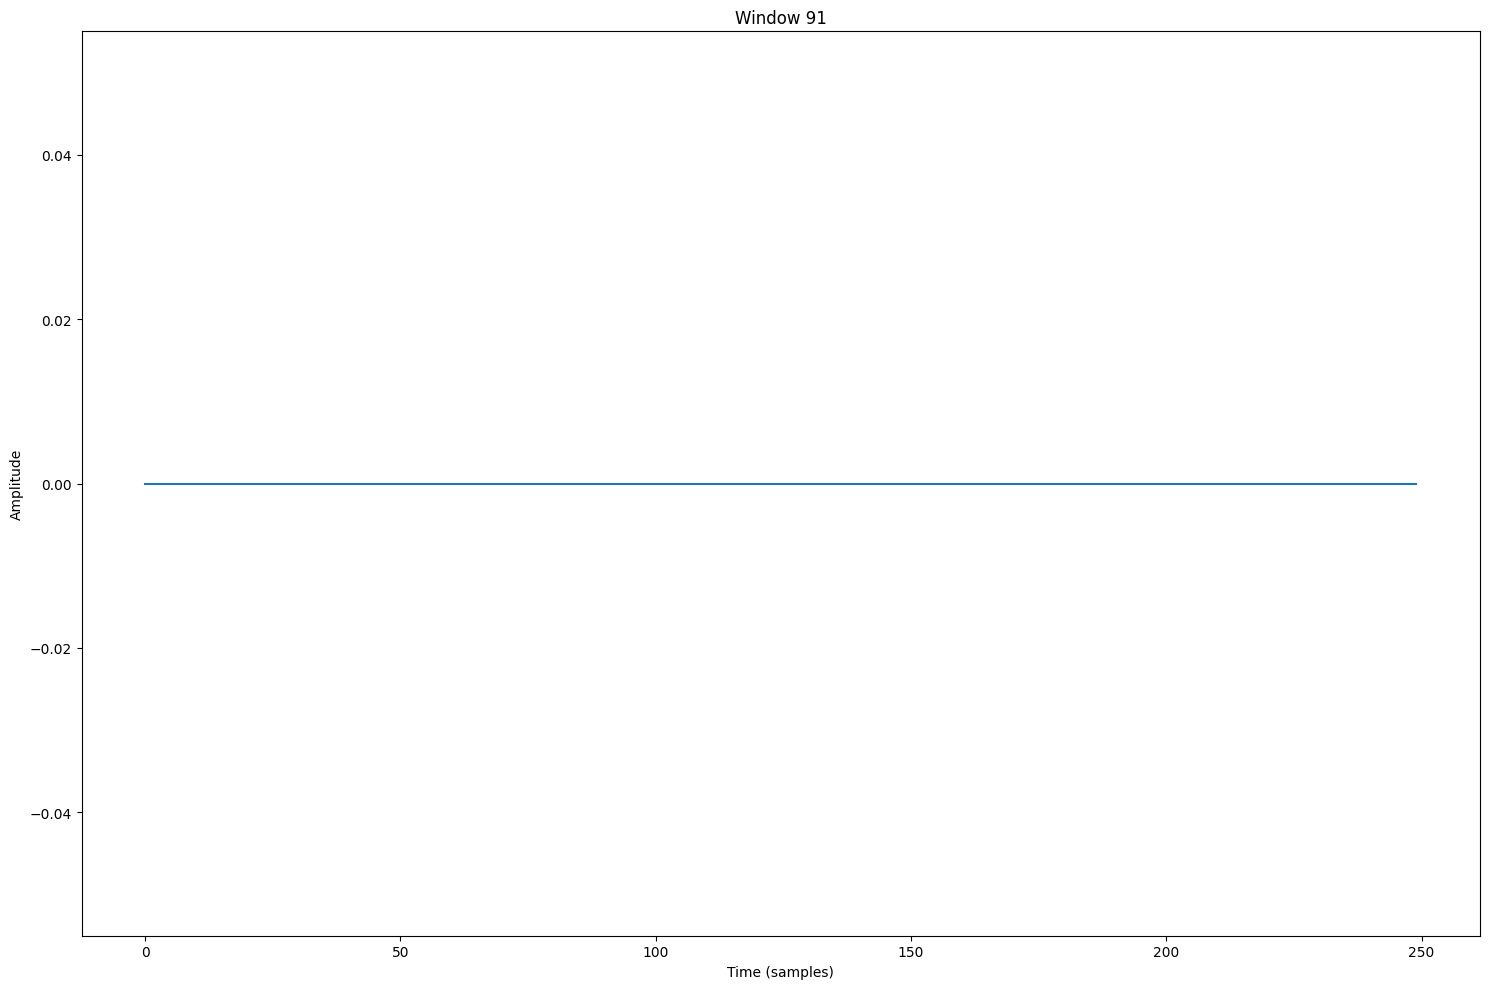

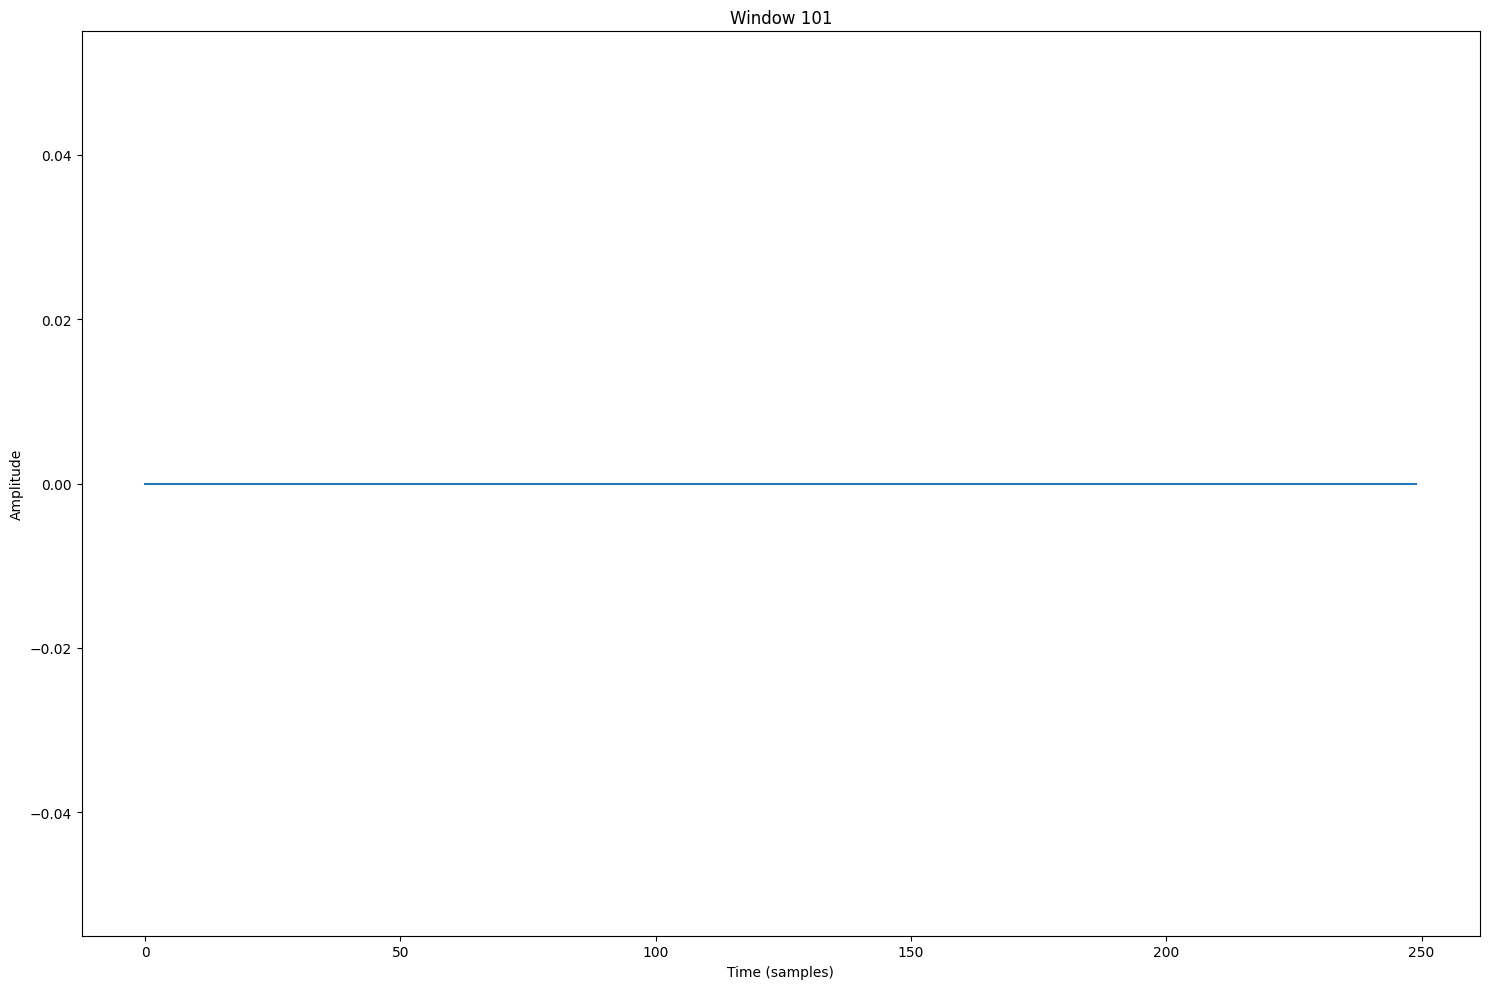

In [8]:
import matplotlib.pyplot as plt

# Fungsi untuk visualisasi time series setiap window
def plot_time_series(window):
    plt.figure(figsize=(15, 10))
    plt.plot(windows[window])
    plt.title(f"Window {window + 1}")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

# Contoh: Plot 5 window pertama Contoh: Plot 5 window pertama
plot_time_series(90)
plot_time_series(100)

In [9]:
from sklearn.preprocessing import MinMaxScaler

# Normalisasi data
scaler = MinMaxScaler(feature_range=(-1, 1))
windows_normalized = scaler.fit_transform(windows)

In [10]:
from scipy.signal import butter, filtfilt

# Fungsi untuk bandpass filter
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=0)

# Contoh: Terapkan bandpass filter (0.5 Hz - 40 Hz)
fs = 250  # Sampling rate
windows_filtered = bandpass_filter(windows_normalized, lowcut=0.5, highcut=40, fs=fs)

In [11]:
from scipy.signal import iirnotch, filtfilt

# Fungsi untuk notch filter
def notch_filter(data, freq, fs, quality_factor=30):
    nyquist = 0.5 * fs
    freq = freq / nyquist
    b, a = iirnotch(freq, quality_factor)
    return filtfilt(b, a, data, axis=0)

# Contoh: Terapkan notch filter (50 Hz)
windows_notch_filtered = notch_filter(windows_filtered, freq=50, fs=fs)

In [12]:
# Fungsi untuk ekstraksi fitur
def extract_features(data):
    features = []
    for window in data:
        mean = np.mean(window)
        std = np.std(window)
        variance = np.var(window)
        features.append([mean, std, variance])
    return np.array(features)

# Ekstraksi fitur dari data yang sudah diproses
features = extract_features(windows_notch_filtered)
print(f"Shape fitur: {features.shape}")

Shape fitur: (1820, 3)


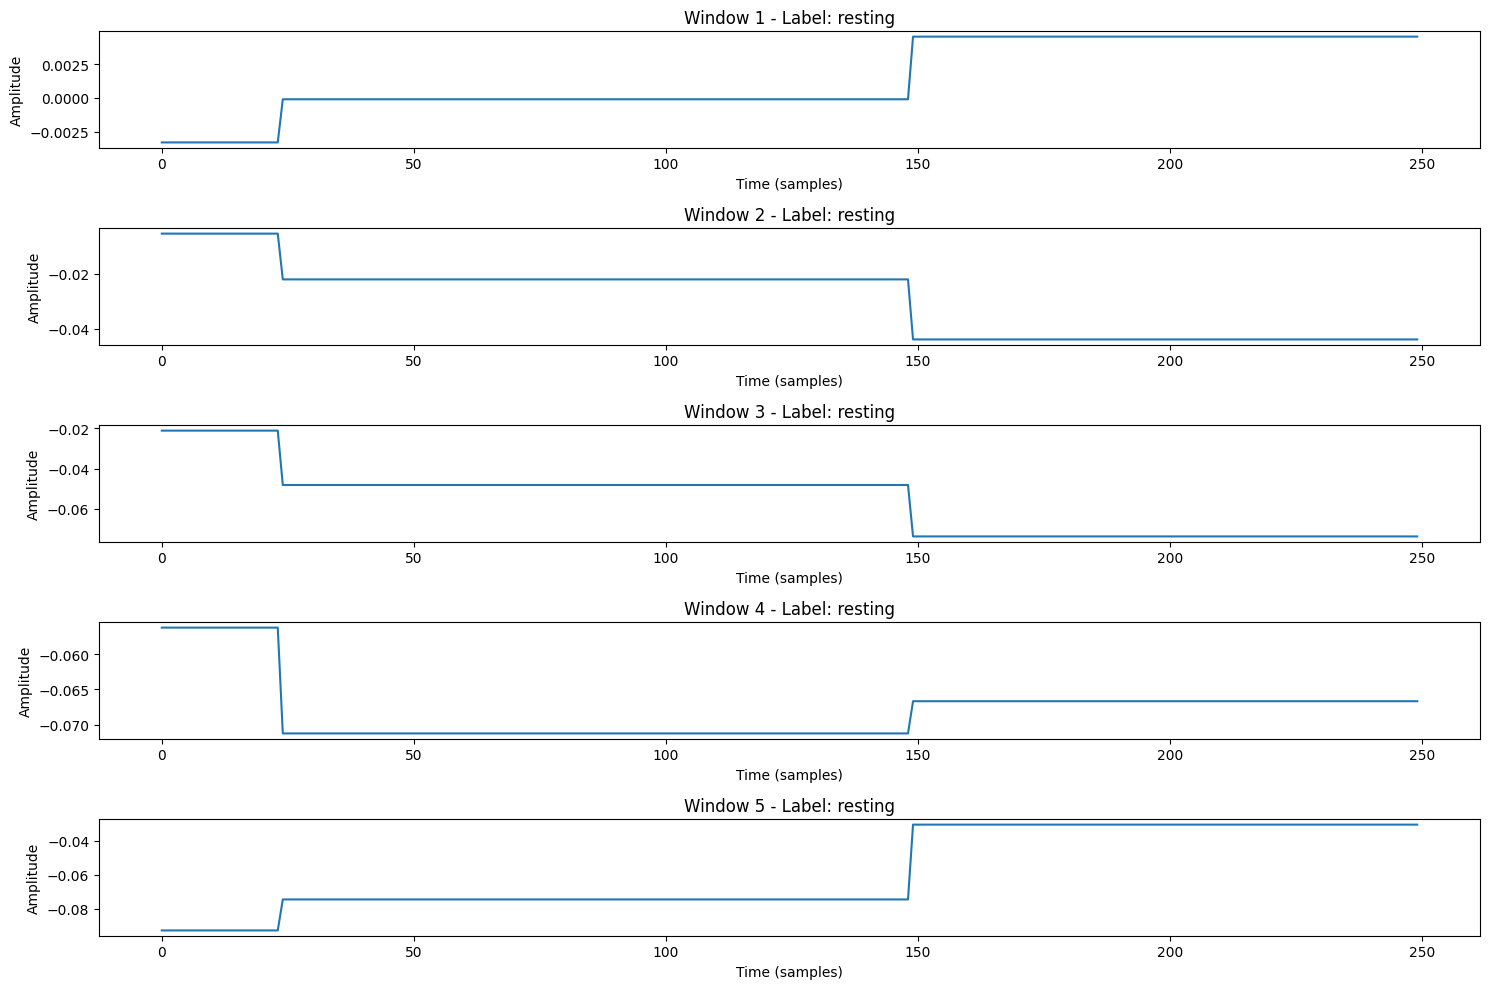

In [13]:
import matplotlib.pyplot as plt

# Fungsi untuk visualisasi time series setiap window
def plot_time_series(windows, window_labels, num_windows_to_plot=5):
    plt.figure(figsize=(15, 10))
    for i in range(num_windows_to_plot):
        plt.subplot(num_windows_to_plot, 1, i + 1)
        plt.plot(windows[i])
        plt.title(f"Window {i + 1} - Label: {window_labels[i]}")
        plt.xlabel("Time (samples)")
        plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

# Contoh: Plot 5 window pertama
plot_time_series(windows_notch_filtered, labels, num_windows_to_plot=5)

In [14]:
# Contoh: Membuat label (misalnya, 0 untuk kelas A, 1 untuk kelas B)
labels = np.array([0] * len(features))  # Ganti dengan label yang sesuai

In [15]:
plt.figure(figsize=(12, 5))
plt.scatter(data["Timestamp (Formatted)"], data["EXG Channel 0"], color='r', s=1)

plt.xlabel("Waktu")
plt.ylabel("Amplitude")
plt.xticks(rotation=45)  # Rotasi label waktu agar lebih terbaca
plt.title("Scatter Plot Sinyal EEG - EXG Channel 0 terhadap Waktu")
plt.grid()
plt.show()


KeyError: 'Timestamp (Formatted)'

<Figure size 1200x500 with 0 Axes>

In [ ]:
def window_function():
    print(True)

In [ ]:
import numpy as np
import scipy.signal as signal
import mne
import pandas as pd
# Contoh data EEG (gantilah dengan data EEG Anda)
# Misalnya, data EEG memiliki 4 channel dan 1000 sample points
eeg_data = pd.read_csv("./data/OpenBCI-RAW-2024-09-04_17-56-48.csv", skiprows=4)
eeg_data.columns = eeg_data.columns.str.strip()
sampling_rate = 250  # Sampling rate 250 Hz

# 1. Windowing
def apply_windowing(data, window_size, overlap):
    """
    Menerapkan windowing pada data EEG.
    
    Parameters:
        data (numpy array): Data EEG dengan bentuk (channel, sample).
        window_size (int): Ukuran window dalam sample.
        overlap (int): Overlap antar window dalam sample.
    
    Returns:
        windowed_data (list): List dari windowed data.
    """
    windowed_data = []
    n_samples = data.shape[1]
    step = window_size - overlap
    
    for start in range(0, n_samples - window_size + 1, step):
        window = data[:, start:start + window_size]
        windowed_data.append(window)
    
    return windowed_data

window_size = 250  # Misalnya, window size 1 detik (250 sample)
overlap = 125  # Overlap 0.5 detik (125 sample)
windowed_data = apply_windowing(eeg_data, window_size, overlap)

# 2. Normalisasi
def normalize_data(data):
    """
    Normalisasi data EEG dengan z-score normalization.
    
    Parameters:
        data (numpy array): Data EEG dengan bentuk (channel, sample).
    
    Returns:
        normalized_data (numpy array): Data EEG yang telah dinormalisasi.
    """
    mean = np.mean(data, axis=1, keepdims=True)
    std = np.std(data, axis=1, keepdims=True)
    normalized_data = (data - mean) / std
    return normalized_data

normalized_data = [normalize_data(window) for window in windowed_data]

# 3. Bandpass Filter
def apply_bandpass_filter(data, lowcut, highcut, fs, order=5):
    """
    Menerapkan bandpass filter pada data EEG.
    
    Parameters:
        data (numpy array): Data EEG dengan bentuk (channel, sample).
        lowcut (float): Frekuensi cutoff rendah (Hz).
        highcut (float): Frekuensi cutoff tinggi (Hz).
        fs (float): Sampling rate (Hz).
        order (int): Order filter.
    
    Returns:
        filtered_data (numpy array): Data EEG yang telah difilter.
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(order, [low, high], btype='band')
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

lowcut = 1.0  # Frekuensi cutoff rendah 1 Hz
highcut = 50.0  # Frekuensi cutoff tinggi 50 Hz
filtered_data = [apply_bandpass_filter(window, lowcut, highcut, sampling_rate) for window in normalized_data]

# 4. Notch Filter
def apply_notch_filter(data, notch_freq, fs, quality_factor=30):
    """
    Menerapkan notch filter pada data EEG.
    
    Parameters:
        data (numpy array): Data EEG dengan bentuk (channel, sample).
        notch_freq (float): Frekuensi notch (Hz).
        fs (float): Sampling rate (Hz).
        quality_factor (float): Quality factor dari filter.
    
    Returns:
        filtered_data (numpy array): Data EEG yang telah difilter.
    """
    nyquist = 0.5 * fs
    freq = notch_freq / nyquist
    b, a = signal.iirnotch(freq, quality_factor)
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

notch_freq = 50.0  # Frekuensi notch 50 Hz (untuk menghilangkan noise listrik)
final_data = [apply_notch_filter(window, notch_freq, sampling_rate) for window in filtered_data]

# Hasil akhir adalah list dari windowed, normalized, dan filtered data
print(final_data)

[]
